# Step 3 — Domain Dictionary Filtering
**Project:** Same Reality, Different Words  
**Author:** Paula Andrea Jaramillo  
**Program:** MSc Data Science for Society and Business — Constructor University Bremen

## Objective
Build a **domain-specific dictionary** of terms related to Colombian labor informality and use it to filter the vocabulary before the TF-IDF analysis in Step 4.

The goal is twofold:
1. **Focus the lexical analysis** on terms that are semantically relevant to the domain, eliminating generic vocabulary that would dilute the signal
2. **Examine how domain terms are distributed across registers** — which register uses more institutional terminology vs. narrative vs. critical vocabulary

**Methodological rationale:**  
Without domain filtering, TF-IDF picks up high-frequency generic terms (e.g., *work*, *people*, *said*) that carry little discriminative power for register classification. A domain dictionary anchors the analysis to the substantive topic.

**Input:** `corpus_pos.csv` (output of Step 2)  
**Output:** `corpus_domain.csv` (adds `text_domain` column with domain-filtered tokens) + `domain_dictionary.json`

## 1. Imports and Setup

In [8]:
import pandas as pd
import json
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Load Corpus

In [9]:
# Adjust path as needed
df = pd.read_csv("corpus_pos.csv")

print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
print(f"Registers: {df['register'].value_counts().to_dict()}")
df[["text_clean", "label", "register"]].head(3)

Rows: 180 | Columns: 20
Registers: {'institutional': 60, 'popular_media': 60, 'critical_media': 60}


,text_clean,label,register
0,colombia share worker lack formal contract reg...,0,institutional
1,social protection coverage account worker info...,0,institutional
2,labor formality indicator main metropolitan ar...,0,institutional


## 3. Domain Dictionary

The dictionary is organized into **6 semantic clusters** reflecting the key conceptual dimensions of Colombian labor informality discourse.

To reduce bias toward institutional wording, the dictionary also includes **high-signal everyday labor vocabulary** that appears in the `popular_media` register (e.g., *work*, *sell*, *pay*, *earn*, *cash*, *street*, *market*).

| Cluster | Description |
|---|---|
| `core_informality` | Direct terms for informal work |
| `institutions_actors` | Organizations, agencies, named actors |
| `legal_regulatory` | Contracts, compliance, legal instruments |
| `social_protection` | Benefits, pensions, health coverage |
| `labor_conditions` | Work conditions, earnings, livelihood constraints |
| `critical_framing` | Terms associated with investigative/critical register |

**Note:** All terms are **lemmatized lowercase** to match the `text_clean` column from Step 1.

In [15]:
DOMAIN_DICTIONARY = {
    "core_informality": [
        "informal", "informality", "informal_work", "informal_sector",
        "informal_employment", "informal_worker", "informalize",
        "precarious", "precarity", "precariousness",
        "unregister", "unregistered", "undeclare",
        "own_account", "self_employ", "self_employed",
        "street_vendor", "vendor", "hustle", "gig",
        "work", "job", "employment", "street", "market", "sell"
    ],
    "institutions_actors": [
        "dane", "ilo", "ministry", "labor_ministry",
        "government", "municipality", "employer", "employee",
        "worker", "labor_inspector", "inspector",
        "union", "federation", "ngo", "cooperative",
        "contractor", "subcontractor", "platform"
    ],
    "legal_regulatory": [
        "contract", "formal_contract", "labor_contract",
        "compliance", "obligation", "contribution", "mandate",
        "regulation", "regulatory", "statute", "statutory",
        "threshold", "affiliation", "registration", "register",
        "formalization", "formalize", "formality", "formal",
        "reform", "policy", "decree", "law", "code", "labor_code"
    ],
    "social_protection": [
        "pension", "pension_system", "pension_fund",
        "health", "health_insurance", "social_security",
        "protection", "social_protection", "benefit",
        "coverage", "affiliation", "contribution",
        "severance", "redundancy", "unemployment_insurance",
        "leave", "guarantee"
    ],
    "labor_conditions": [
        "wage", "salary", "income", "earning", "earn", "pay", "cash",
        "minimum_wage", "poverty", "vulnerability",
        "hour", "working_hour", "overtime", "daily",
        "exploitation", "precarious", "labor", "repair",
        "rural", "urban", "metropolitan", "region",
        "gender", "woman", "youth", "migrant", "domestic",
        "tip", "commission", "saving", "cost", "food"
    ],
    "critical_framing": [
        "structural", "systemic", "reproduce", "perpetuate",
        "inequality", "exclusion", "marginalization",
        "abandon", "neglect", "impunity",
        "denounce", "denouncement", "reveal", "expose",
        "finding", "hallazgo", "evidence", "document",
        "accountability", "consequence", "impact"
    ]
}

# Flat set of all domain terms for filtering
ALL_DOMAIN_TERMS = set()
for cluster, terms in DOMAIN_DICTIONARY.items():
    ALL_DOMAIN_TERMS.update(terms)

print(f"Total domain clusters: {len(DOMAIN_DICTIONARY)}")
print(f"Total unique domain terms: {len(ALL_DOMAIN_TERMS)}")
print()
for cluster, terms in DOMAIN_DICTIONARY.items():
    print(f"  {cluster}: {len(terms)} terms")

Total domain clusters: 6
Total unique domain terms: 136

  core_informality: 26 terms
  institutions_actors: 18 terms
  legal_regulatory: 25 terms
  social_protection: 17 terms
  labor_conditions: 32 terms
  critical_framing: 21 terms


## 4. Apply Domain Filter

We filter `text_clean` (already lemmatized and lowercased from Step 1), keeping only **single-word tokens** that appear in the domain dictionary.  
This step is intentionally conservative: compound terms with underscores are kept in the dictionary for documentation, but the implemented filter below matches only the lemmatized single-token vocabulary present in `text_clean`.

In [16]:
# Single-word terms only (underscore terms are conceptual labels, not in text_clean)
SINGLE_TERMS = {t for t in ALL_DOMAIN_TERMS if "_" not in t}

def filter_domain_tokens(text_clean):
    """
    Given a cleaned/lemmatized text string, return only tokens
    that appear in the domain dictionary (single-word terms).
    Returns a space-joined string of domain tokens.
    """
    if not isinstance(text_clean, str):
        return ""
    tokens = text_clean.split()
    domain_tokens = [t for t in tokens if t in SINGLE_TERMS]
    return " ".join(domain_tokens)

def count_domain_tokens(text_clean):
    """Count how many domain tokens are in the text."""
    if not isinstance(text_clean, str):
        return 0
    tokens = text_clean.split()
    return sum(1 for t in tokens if t in SINGLE_TERMS)

# Apply
df["text_domain"] = df["text_clean"].apply(filter_domain_tokens)
df["domain_token_count"] = df["text_clean"].apply(count_domain_tokens)
df["domain_coverage"] = (df["domain_token_count"] / df["token_count_clean"]).round(4)

print("Domain filtering applied.")
print(f"Mean domain token count: {df['domain_token_count'].mean():.2f}")
print(f"Mean domain coverage: {df['domain_coverage'].mean():.3f} ({df['domain_coverage'].mean()*100:.1f}%)")
print()
df[["register", "token_count_clean", "domain_token_count", "domain_coverage", "text_domain"]].head(5)

Domain filtering applied.
Mean domain token count: 4.62
Mean domain coverage: 0.246 (24.6%)



,register,token_count_clean,domain_token_count,domain_coverage,text_domain
0,institutional,18,8,0.4444,worker formal contract registration urban rura...
1,institutional,18,8,0.4444,protection coverage worker informal statutory ...
2,institutional,15,9,0.6000,labor formality metropolitan employer complian...
3,institutional,16,5,0.3125,informal employment worker structural formality
4,institutional,18,7,0.3889,reveal woman domestic formal contract affiliat...


## 5. Domain Coverage by Register

In [5]:
coverage_by_register = df.groupby("register")[["domain_token_count", "domain_coverage"]].agg(
    mean_domain_tokens=("domain_token_count", "mean"),
    std_domain_tokens=("domain_token_count", "std"),
    mean_coverage=("domain_coverage", "mean"),
    min_coverage=("domain_coverage", "min"),
    max_coverage=("domain_coverage", "max")
).round(4)

print("Domain coverage by register:")
print(coverage_by_register.to_string())

Domain coverage by register:
                mean_domain_tokens  std_domain_tokens  mean_coverage  min_coverage  max_coverage
register                                                                                        
critical_media              3.5833             2.1573         0.1479          0.00        0.3913
institutional               3.2833             1.6682         0.1825          0.05        0.5333
popular_media               1.5333             1.1712         0.1051          0.00        0.3571


## 6. Cluster-Level Analysis

For each register, compute how many tokens belong to each semantic cluster.  
This reveals which registers rely more on institutional vocabulary vs. critical framing.

In [18]:
# Build reverse lookup: token → cluster
TOKEN_TO_CLUSTER = {}
for cluster, terms in DOMAIN_DICTIONARY.items():
    for term in terms:
        if "_" not in term:  # single-word terms only
            TOKEN_TO_CLUSTER[term] = cluster

def count_by_cluster(text_clean):
    """Returns a dict with count per cluster for a given text."""
    if not isinstance(text_clean, str):
        return {c: 0 for c in DOMAIN_DICTIONARY}
    tokens = text_clean.split()
    cluster_counts = {c: 0 for c in DOMAIN_DICTIONARY}
    for token in tokens:
        if token in TOKEN_TO_CLUSTER:
            cluster_counts[TOKEN_TO_CLUSTER[token]] += 1
    return cluster_counts

cluster_data = df["text_clean"].apply(count_by_cluster)
cluster_df = pd.DataFrame(cluster_data.tolist())
df_cluster = pd.concat([df[["register", "label"]], cluster_df], axis=1)

# Mean cluster counts by register
cluster_by_register = df_cluster.groupby("register")[list(DOMAIN_DICTIONARY.keys())].mean().round(3)
print("Mean cluster token counts by register:")
print(cluster_by_register.to_string())

Mean cluster token counts by register:
                core_informality  institutions_actors  legal_regulatory  social_protection  labor_conditions  critical_framing
register                                                                                                                      
critical_media             1.100                1.133             0.933              0.550             1.233             0.267
institutional              1.517                0.733             1.083              0.533             0.850             0.150
popular_media              1.333                0.200             0.283              0.417             1.517             0.017


## 7. Visualizations

### 7.1 Domain Coverage by Register — Boxplot

C:\Users\jaram\AppData\Local\Temp\ipykernel_15492\2976070587.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_reg, labels=register_labels, patch_artist=True,


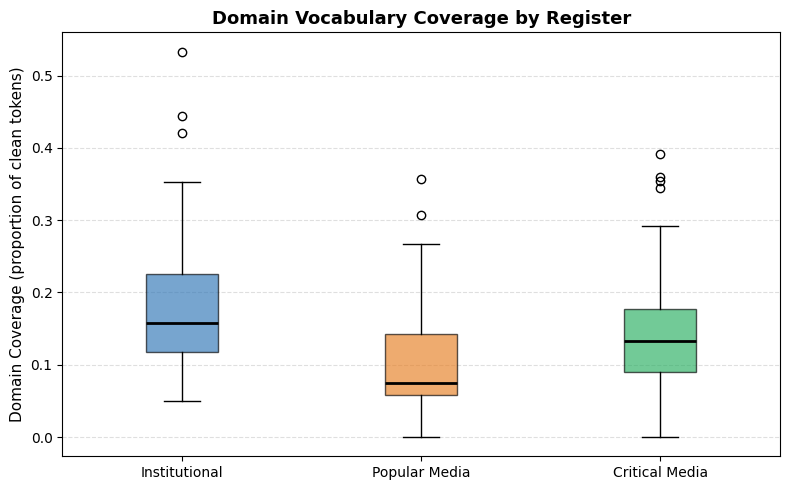

Figure saved: step3_coverage_boxplot.png


In [7]:
register_order = ["institutional", "popular_media", "critical_media"]
register_labels = ["Institutional", "Popular Media", "Critical Media"]
colors = ["#2E75B6", "#E67E22", "#27AE60"]

fig, ax = plt.subplots(figsize=(8, 5))
data_by_reg = [df[df["register"] == reg]["domain_coverage"].values for reg in register_order]
bp = ax.boxplot(data_by_reg, labels=register_labels, patch_artist=True,
                medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

ax.set_ylabel("Domain Coverage (proportion of clean tokens)", fontsize=11)
ax.set_title("Domain Vocabulary Coverage by Register", fontsize=13, fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("step3_coverage_boxplot.png", dpi=150)
plt.show()
print("Figure saved: step3_coverage_boxplot.png")

### 7.2 Cluster Profile by Register — Stacked Bar Chart

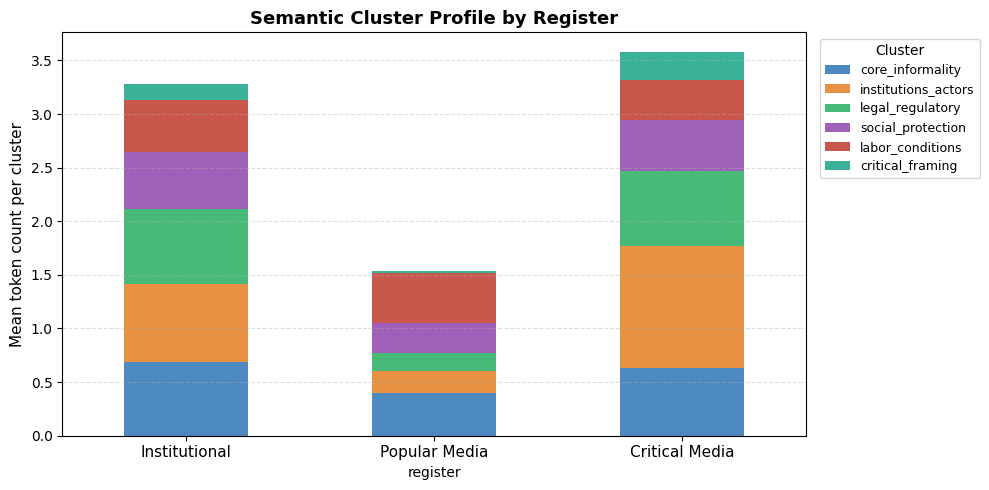

Figure saved: step3_cluster_profile.png


In [8]:
cluster_colors = ["#2E75B6", "#E67E22", "#27AE60", "#8E44AD", "#C0392B", "#17A589"]
cluster_plot = cluster_by_register.loc[register_order]

fig, ax = plt.subplots(figsize=(10, 5))
cluster_plot.plot(kind="bar", stacked=True, ax=ax, color=cluster_colors, alpha=0.85, width=0.5)

ax.set_xticklabels(register_labels, rotation=0, fontsize=11)
ax.set_ylabel("Mean token count per cluster", fontsize=11)
ax.set_title("Semantic Cluster Profile by Register", fontsize=13, fontweight="bold")
ax.legend(title="Cluster", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("step3_cluster_profile.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: step3_cluster_profile.png")

### 7.3 Top Domain Terms per Register — Bar Charts

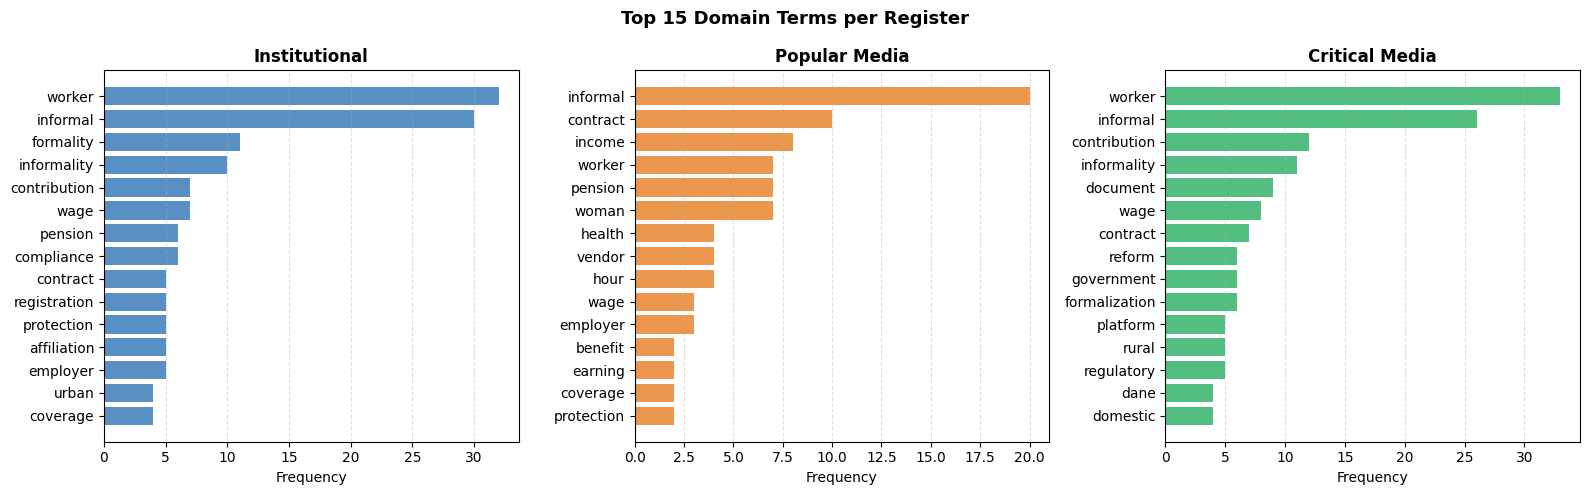

Figure saved: step3_top_terms_per_register.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, reg, label, color in zip(axes, register_order, register_labels, colors):
    texts = df[df["register"] == reg]["text_clean"].tolist()
    all_tokens = []
    for text in texts:
        if isinstance(text, str):
            all_tokens.extend([t for t in text.split() if t in SINGLE_TERMS])
    top15 = Counter(all_tokens).most_common(15)
    if top15:
        words, counts = zip(*top15)
        ax.barh(list(words)[::-1], list(counts)[::-1], color=color, alpha=0.8)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel("Frequency", fontsize=10)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.suptitle("Top 15 Domain Terms per Register", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("step3_top_terms_per_register.png", dpi=150)
plt.show()
print("Figure saved: step3_top_terms_per_register.png")

## 8. Quality Check — Empty text_domain Documents

Documents with zero domain tokens after filtering are problematic for Steps 4–6.  
We flag and inspect them here.

In [17]:
empty_docs = df[df["domain_token_count"] == 0]
print(f"Documents with zero domain tokens: {len(empty_docs)}")

if len(empty_docs) > 0:
    print("\nInspect these documents:")
    print(empty_docs[["prompt_id", "register", "text_clean", "domain_token_count"]].to_string())
    print("\n⚠️  WARNING: These documents will produce empty TF-IDF rows in Step 4.")
    print("Consider expanding the domain dictionary or excluding them with justification.")

    popular_empty = empty_docs[empty_docs["register"] == "popular_media"]
    if len(popular_empty) > 0:
        uncovered = Counter()
        for text in popular_empty["text_clean"]:
            uncovered.update(str(text).split())
        print("\nTop uncovered tokens in zero-hit popular_media documents:")
        print(uncovered.most_common(20))
else:
    print("✅ All documents contain at least one domain token. Safe to proceed to Step 4.")

print(f"\nMinimum domain tokens per document: {df['domain_token_count'].min()}")
print(f"Maximum domain tokens per document: {df['domain_token_count'].max()}")

Documents with zero domain tokens: 0
✅ All documents contain at least one domain token. Safe to proceed to Step 4.

Minimum domain tokens per document: 1
Maximum domain tokens per document: 13


## 9. Save Outputs

In [19]:
# Save enriched corpus
df_out = pd.concat([df, cluster_df[list(DOMAIN_DICTIONARY.keys())]], axis=1)
df_out.to_csv("corpus_domain.csv", index=False)
print(f"Saved: corpus_domain.csv — shape: {df_out.shape}")

# Save dictionary as JSON for reproducibility documentation
with open("domain_dictionary.json", "w", encoding="utf-8") as f:
    json.dump(DOMAIN_DICTIONARY, f, indent=2, ensure_ascii=False)
print("Saved: domain_dictionary.json")

print(f"\nColumns in corpus_domain.csv:")
print(df_out.columns.tolist())

Saved: corpus_domain.csv — shape: (180, 29)
Saved: domain_dictionary.json

Columns in corpus_domain.csv:
['text', 'text_clean', 'label', 'register', 'prompt_id', 'token_count_original', 'token_count_clean', 'total_tokens', 'count_noun', 'ratio_noun', 'count_verb', 'ratio_verb', 'count_adj', 'ratio_adj', 'count_adv', 'ratio_adv', 'count_propn', 'ratio_propn', 'count_num', 'ratio_num', 'text_domain', 'domain_token_count', 'domain_coverage', 'core_informality', 'institutions_actors', 'legal_regulatory', 'social_protection', 'labor_conditions', 'critical_framing']


## 10. Summary

In [12]:
print("=== STEP 3 SUMMARY ===")
print(f"Domain dictionary: {len(DOMAIN_DICTIONARY)} clusters, {len(SINGLE_TERMS)} single-word terms")
print(f"\nDomain coverage by register:")
print(df.groupby("register")["domain_coverage"].mean().round(3).to_string())
print(f"\nSemantic cluster profile:")
print(cluster_by_register.to_string())
print("\nNext step: Step 4 — TF-IDF Divergence")
print("Input file for Step 4: corpus_domain.csv (column: text_domain)")

=== STEP 3 SUMMARY ===
Domain dictionary: 6 clusters, 95 single-word terms

Domain coverage by register:
register
critical_media    0.148
institutional     0.182
popular_media     0.105

Semantic cluster profile:
                core_informality  institutions_actors  legal_regulatory  social_protection  labor_conditions  critical_framing
register                                                                                                                      
critical_media             0.633                1.133             0.700              0.483             0.367             0.267
institutional              0.683                0.733             0.700              0.533             0.483             0.150
popular_media              0.400                0.200             0.167              0.283             0.467             0.017

Next step: Step 4 — TF-IDF Divergence
Input file for Step 4: corpus_domain.csv (column: text_domain)
